# 03. Modelo Prophet: entrenamiento y evaluación comparativa

Este notebook se entrena el modelo predictivo principal
del sistema, basado en Prophet. Prophet es una biblioteca de predicción
de series temporales desarrollada por Meta (anteriormente Facebook)
que modela la demanda como la suma de una tendencia no lineal, varias
componentes estacionales (diaria, semanal, anual) y un término de
efectos de festivos, admitiendo además regresores externos.

El objetivo del notebook es:

- Entrenar un modelo Prophet **base** sin regresores externos, como
  punto de partida de referencia.
- Incorporar progresivamente los componentes adicionales (festivos y
  dos variantes de clima) para medir la aportación de cada uno.
- Comparar las distintas configuraciones mediante métricas de error
  (MAE, RMSE, MAPE) evaluadas sobre un conjunto de test independiente.
- Realizar validación cruzada temporal de las configuraciones más prometedoras en dos escenarios operativos
- Guardar el modelo final entrenado para su uso posterior en el panel
  de visualización.

La fuente de datos es el dataset enriquecido generado en el notebook
anterior (`data/processed/dataset_enriquecido.csv`), que contiene la
serie diaria de pedidos junto con las variables contextuales de clima
y festivos.


Para el caso de estudio:
- Datos de entrenamiento: 01/09/2016 - 04/05/2019 (977 días)
- Datos de test: 06/05/2019 - 03/08/2019 (90 días)

## 1. Configuración inicial y carga del dataset enriquecido

Se cargan los paquetes necesarios y el dataset enriquecido generado en
el notebook anterior. Este dataset contiene la serie objetivo y todas
las variables contextuales listas para el entrenamiento.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from prophet import Prophet
import logging
import os


# Filtramos los warnings non-fatal de Stan durante el muestreo MCMC.
# Estos warnings aparecen durante la fase de warmup cuando Stan explora
# valores extremos para encontrar el espacio óptimo de parámetros, pero
# no afectan al resultado final del muestreo.
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.CRITICAL)
os.environ['CMDSTAN_NO_WARNINGS'] = '1'

# Rutas del proyecto
DATA_PROCESSED = Path("../data/processed")

# Carga del dataset enriquecido
dataset = pd.read_csv(
    DATA_PROCESSED / "dataset_enriquecido.csv",
    parse_dates=["fecha"]
)

print(f"Dataset cargado: {len(dataset):,} días × {dataset.shape[1]} columnas")
print(f"Rango temporal: {dataset['fecha'].min().date()} → {dataset['fecha'].max().date()}")
print(f"\nColumnas disponibles:")
for col in dataset.columns:
    print(f"  - {col}")
print(f"\nPrimeras 3 filas:")
dataset.head(3)

Dataset cargado: 1,067 días × 18 columnas
Rango temporal: 2016-09-01 → 2019-08-03

Columnas disponibles:
  - fecha
  - n_pedidos
  - es_festivo
  - festivo_nombre
  - temp_media_dia
  - precipitacion_total_dia
  - viento_medio_dia
  - humedad_media_dia
  - nubosidad_media_dia
  - temp_media_serv
  - precipitacion_total_serv
  - viento_medio_serv
  - humedad_media_serv
  - nubosidad_media_serv
  - dia_semana
  - dia_semana_es
  - mediana_dow
  - zscore

Primeras 3 filas:


,fecha,n_pedidos,es_festivo,festivo_nombre,temp_media_dia,precipitacion_total_dia,viento_medio_dia,humedad_media_dia,nubosidad_media_dia,temp_media_serv,precipitacion_total_serv,viento_medio_serv,humedad_media_serv,nubosidad_media_serv,dia_semana,dia_semana_es,mediana_dow,zscore
0,2016-09-01,10,0,NaN,17.42,0.0,9.65,73.38,68.83,19.96,0.0,11.90,59.86,76.0,Thursday,Jueves,11.0,-0.171926
1,2016-09-02,20,0,NaN,17.14,1.3,14.96,82.58,98.29,18.51,0.0,15.37,81.43,100.0,Friday,Viernes,25.0,-0.743660
2,2016-09-03,35,0,NaN,16.83,2.8,17.54,81.54,96.54,17.91,2.6,22.94,85.86,100.0,Saturday,Sábado,39.0,-0.455808


## 2. Preparación de los datos en formato Prophet

Prophet exige que el DataFrame de entrada tenga una estructura concreta:
- una columna `ds` con las fechas 
- y una columna `y` con los valores de la
serie objetivo. 

Los regresores externos se añaden como columnas
adicionales con el nombre que se desee.

En este apartado se adapta el dataset enriquecido al formato esperado
por Prophet, renombrando la columna `fecha` a `ds` y la columna
`n_pedidos` a `y`. Los regresores se conservan con los nombres
descriptivos actuales para facilitar la interpretación de los
resultados.

In [3]:
# Prophet requiere columnas 'ds' (fecha) y 'y' (valor objetivo)
df_prophet = dataset.rename(columns={
    "fecha": "ds",
    "n_pedidos": "y"
})

# La columna festivo_nombre no la necesita Prophet, pero la conservamos
# para análisis posterior. El indicador es_festivo lo trataremos aparte.
print(f"DataFrame adaptado para Prophet: {len(df_prophet):,} filas × {df_prophet.shape[1]} columnas")
print(f"\nPrimeras 3 filas:")
df_prophet.head(3)

DataFrame adaptado para Prophet: 1,067 filas × 18 columnas

Primeras 3 filas:


,ds,y,es_festivo,festivo_nombre,temp_media_dia,precipitacion_total_dia,viento_medio_dia,humedad_media_dia,nubosidad_media_dia,temp_media_serv,precipitacion_total_serv,viento_medio_serv,humedad_media_serv,nubosidad_media_serv,dia_semana,dia_semana_es,mediana_dow,zscore
0,2016-09-01,10,0,NaN,17.42,0.0,9.65,73.38,68.83,19.96,0.0,11.90,59.86,76.0,Thursday,Jueves,11.0,-0.171926
1,2016-09-02,20,0,NaN,17.14,1.3,14.96,82.58,98.29,18.51,0.0,15.37,81.43,100.0,Friday,Viernes,25.0,-0.743660
2,2016-09-03,35,0,NaN,16.83,2.8,17.54,81.54,96.54,17.91,2.6,22.94,85.86,100.0,Saturday,Sábado,39.0,-0.455808


## 3. División en conjuntos de entrenamiento y test

Para poder evaluar la calidad de las predicciones se divide el dataset en dos conjuntos:

- **Entrenamiento:** el modelo aprende de estos datos. Se corresponde
  con la parte más antigua de la serie.
- **Test:** el modelo no accede a estos datos durante el entrenamiento. Se
  utilizan para comparar las predicciones del modelo con los valores
  reales y calcular las métricas de error.

A diferencia de algoritmos de clasificación, donde la división suele
hacerse aleatoriamente, en series temporales la división debe
respetar el orden cronológico. Entrenar con datos del futuro para
predecir el pasado (data leakage) produciría métricas buenas que no reflejarían el comportamiento real del modelo en
producción.

Se reservan como test los últimos 90 días del dataset (aproximadamente
el 8%). Este periodo equivale al horizonte de predicción habitual en
restauración (un trimestre) y es suficientemente amplio para que las
métricas sean estables, pero no tanto como para reducir
significativamente los datos de entrenamiento.

In [4]:
# Reservamos los últimos 90 días como test (horizonte trimestral)
N_DIAS_TEST = 90

df_train = df_prophet.iloc[:-N_DIAS_TEST].copy()
df_test = df_prophet.iloc[-N_DIAS_TEST:].copy()

print(f"Conjunto de entrenamiento: {len(df_train):,} días")
print(f"  Rango: {df_train['ds'].min().date()} → {df_train['ds'].max().date()}")
print(f"\nConjunto de test: {len(df_test):,} días")
print(f"  Rango: {df_test['ds'].min().date()} → {df_test['ds'].max().date()}")
print(f"\nProporción test / total: {len(df_test) / len(df_prophet) * 100:.1f}%")

Conjunto de entrenamiento: 977 días
  Rango: 2016-09-01 → 2019-05-05

Conjunto de test: 90 días
  Rango: 2019-05-06 → 2019-08-03

Proporción test / total: 8.4%


## 4. Modelo base (solo serie temporal)

Se entrena un primer modelo Prophet utilizando únicamente la
información temporal de la serie de pedidos, sin incorporar ningún
regresor externo ni los festivos. Este modelo representa el
comportamiento que se obtendría aplicando Prophet "directamente" a la
serie, y sirve como referencia para cuantificar la mejora que aportan
las variables contextuales en los modelos posteriores.

La configuración de Prophet se deja en sus valores por defecto en
todos los parámetros estacionales salvo los que se adaptan al
problema. En particular, se desactiva la estacionalidad diaria
(`daily_seasonality=False`) porque los datos son diarios y no hay
información intradía que modelar. Se dejan activas la estacionalidad
semanal (para captar el patrón de fines de semana frente a días
laborables) y la estacionalidad anual (para captar patrones
estacionales a lo largo del año).

In [5]:
# Construcción del modelo base: sin regresores externos ni festivos
modelo_base = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
)

# Prophet solo necesita las columnas ds e y, así que le pasamos solo esas
modelo_base.fit(df_train[["ds", "y"]])

print("Modelo base entrenado correctamente.")

12:31:40 - cmdstanpy - INFO - Chain [1] start processing
12:31:40 - cmdstanpy - INFO - Chain [1] done processing


Modelo base entrenado correctamente.


## 5. Predicción del modelo base sobre el conjunto de test

Una vez entrenado el modelo se generan las predicciones para las fechas
del conjunto de test y se comparan con los valores reales.

Prophet realiza las predicciones a través del método `predict`, al que
se le pasa un DataFrame con las fechas (columna `ds`) sobre las que se
quieren obtener resultados. En este caso se utiliza directamente el
conjunto de test, que ya contiene las fechas a predecir.

El método devuelve un DataFrame con la predicción puntual (`yhat`),
los límites del intervalo de confianza (`yhat_lower`, `yhat_upper`) y
las componentes individuales que conforman la predicción (tendencia,
estacionalidades, regresores).

In [6]:
# Generamos las predicciones sobre las fechas del conjunto de test
predicciones_base = modelo_base.predict(df_test[["ds"]])

print(f"Predicciones generadas: {len(predicciones_base):,} días")
print(f"\nColumnas devueltas por Prophet:")
for col in predicciones_base.columns:
    print(f"  - {col}")

print(f"\nPrimeras 3 predicciones (valores clave):")
predicciones_base[["ds", "yhat", "yhat_lower", "yhat_upper"]].head(3)

Predicciones generadas: 90 días

Columnas devueltas por Prophet:
  - ds
  - trend
  - yhat_lower
  - yhat_upper
  - trend_lower
  - trend_upper
  - additive_terms
  - additive_terms_lower
  - additive_terms_upper
  - weekly
  - weekly_lower
  - weekly_upper
  - yearly
  - yearly_lower
  - yearly_upper
  - multiplicative_terms
  - multiplicative_terms_lower
  - multiplicative_terms_upper
  - yhat

Primeras 3 predicciones (valores clave):


,ds,yhat,yhat_lower,yhat_upper
0,2019-05-06,14.000454,5.802487,21.067842
1,2019-05-07,13.200694,5.891190,20.755820
2,2019-05-08,14.447475,6.057260,21.911977


## 6. Métricas de evaluación

Se calculan tres métricas estándar para evaluar la calidad de las
predicciones:

- **MAE (Mean Absolute Error):** el error promedio en valor absoluto,
  expresado en la misma unidad que la variable objetivo (número de
  pedidos).Interpretación: "el modelo se equivoca en media en
  X pedidos por día".
- **RMSE (Root Mean Squared Error):** la raíz del error cuadrático
  medio. Penaliza más los errores grandes que el MAE. Útil cuando
  equivocarse mucho un día es peor que equivocarse poco varios días.
- **MAPE (Mean Absolute Percentage Error):** el error porcentual
  medio. Es adimensional y facilita la comparación entre modelos o
  periodos, aunque puede dar valores extremos si hay días con pocos
  pedidos (división por valores pequeños).

Se definen las funciones de cálculo de forma explícita para tener
control sobre la implementación y poder reutilizarlas en los siguientes
modelos.

In [7]:
def calcular_metricas(y_real: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Calcula las métricas de evaluación estándar para series temporales.
    
    Parámetros
    ----------
    y_real : valores reales observados.
    y_pred : predicciones del modelo.
    
    Devuelve
    --------
    Diccionario con las métricas MAE, RMSE y MAPE.
    
    Nota: el MAPE se calcula excluyendo los días con y_real=0 (días de
    cierre del restaurante), evitando la división por cero. Si todos
    los valores reales son cero, el MAPE se reporta como NaN.
    """
    error = y_real - y_pred
    mae = np.abs(error).mean()
    rmse = np.sqrt((error ** 2).mean())
    
    # MAPE: filtramos los días con valor real igual a cero (cierres)
    # para evitar división por cero y resultados infinitos.
    mask_no_cero = y_real > 0
    if mask_no_cero.sum() > 0:
        mape = (np.abs(error[mask_no_cero] / y_real[mask_no_cero]) * 100).mean()
    else:
        mape = np.nan
    
    return {
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE": round(mape, 2) if not np.isnan(mape) else np.nan,
    }

In [8]:
# Calculamos las métricas del modelo base
metricas_base = calcular_metricas(
    y_real=df_test["y"].values,
    y_pred=predicciones_base["yhat"].values
)

print("Métricas del modelo base (sin regresores):")
for metrica, valor in metricas_base.items():
    unidad = "pedidos" if metrica in ("MAE", "RMSE") else "%"
    print(f"  {metrica}: {valor} {unidad}")

Métricas del modelo base (sin regresores):
  MAE: 4.79 pedidos
  RMSE: 6.17 pedidos
  MAPE: 36.14 %


In [9]:
def resumen_cv(cv_resultados: pd.DataFrame, nombre: str = "") -> dict:
    """
    Calcula las métricas agregadas sobre los resultados de una
    validación cruzada de Prophet.
    
    Parámetros
    ----------
    cv_resultados : DataFrame devuelto por cross_validation de Prophet.
    nombre : etiqueta del modelo (opcional, para contextualizar).
    
    Devuelve
    --------
    Diccionario con MAE, RMSE, MAPE, número de folds y predicciones.
    """
    metricas = calcular_metricas(
        y_real=cv_resultados["y"].values,
        y_pred=cv_resultados["yhat"].values
    )
    metricas["Nº folds"] = cv_resultados["cutoff"].nunique()
    metricas["Nº predicciones"] = len(cv_resultados)
    return metricas

## 7. Visualización del modelo base

Se representa gráficamente la predicción del modelo base sobre el
conjunto de test frente a los valores reales observados. La gráfica
incluye el intervalo de confianza del 80% devuelto por Prophet,
permitiendo ver no solo el error puntual sino también la incertidumbre
que el modelo asocia a cada predicción.

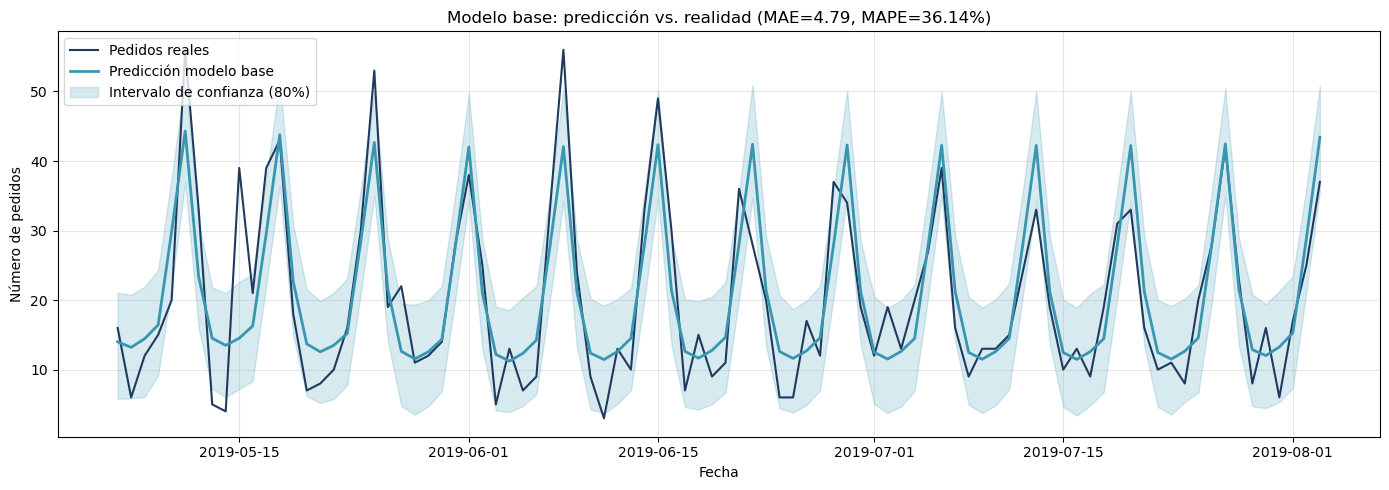

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

# Valores reales del test
ax.plot(df_test["ds"], df_test["y"], 
        label="Pedidos reales", color="#1f3a5f", linewidth=1.5)

# Predicción del modelo
ax.plot(predicciones_base["ds"], predicciones_base["yhat"],
        label="Predicción modelo base", color="#3896b0", linewidth=2)

# Intervalo de confianza
ax.fill_between(
    predicciones_base["ds"],
    predicciones_base["yhat_lower"],
    predicciones_base["yhat_upper"],
    color="#3896b0", alpha=0.2, label="Intervalo de confianza (80%)"
)

ax.set_title(f"Modelo base: predicción vs. realidad (MAE={metricas_base['MAE']}, MAPE={metricas_base['MAPE']}%)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de pedidos")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Modelo con festivos

Se entrena una segunda variante del modelo incorporando los festivos
identificados en el notebook anterior. Prophet admite los festivos a
través del parámetro `holidays` del constructor, que espera un
DataFrame con al menos dos columnas: `ds` (fecha del festivo) y
`holiday` (nombre del festivo, que Prophet usa como identificador).

A diferencia de incorporar los festivos como un simple regresor
binario, este planteamiento permite a Prophet aprender un efecto
específico para cada festivo individual. Así, puede capturar que
Christmas Day tiene un impacto muy distinto al del May Day, lo que
sería imposible si los tratáramos a todos como una variable única.

Se mantiene exactamente la misma configuración que en el modelo base
en el resto de parámetros, de forma que la única diferencia sea la
incorporación de los festivos. Esto permite atribuir cualquier cambio
en las métricas únicamente a su efecto.

In [11]:
# Preparamos el DataFrame de festivos en el formato que Prophet espera
# Prophet necesita columnas 'ds' y 'holiday'
festivos_prophet = dataset[["fecha", "festivo_nombre"]].dropna().copy()
festivos_prophet = festivos_prophet.rename(columns={
    "fecha": "ds",
    "festivo_nombre": "holiday"
})

print(f"Festivos incorporados al modelo: {len(festivos_prophet)}")
print(f"\nPrimeros 5:")
print(festivos_prophet.head().to_string(index=False))

# Construimos el modelo con festivos
modelo_festivos = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

modelo_festivos.fit(df_train[["ds", "y"]])

print("\nModelo con festivos entrenado correctamente.")

12:31:40 - cmdstanpy - INFO - Chain [1] start processing


Festivos incorporados al modelo: 37

Primeros 5:
        ds                  holiday
2016-12-24            Christmas Eve
2016-12-25            Christmas Day
2016-12-26               Boxing Day
2016-12-27 Christmas Day (observed)
2016-12-31           New Year's Eve


12:31:41 - cmdstanpy - INFO - Chain [1] done processing



Modelo con festivos entrenado correctamente.


## 9. Predicción y evaluación del modelo con festivos

Se genera la predicción sobre el conjunto de test, se calculan las
métricas y se compara con las del modelo base para cuantificar la
aportación de los festivos.

In [12]:
# Predicción sobre el test
predicciones_festivos = modelo_festivos.predict(df_test[["ds"]])

# Cálculo de métricas
metricas_festivos = calcular_metricas(
    y_real=df_test["y"].values,
    y_pred=predicciones_festivos["yhat"].values
)

# Tabla comparativa
comparativa = pd.DataFrame({
    "Modelo base": metricas_base,
    "Modelo + festivos": metricas_festivos,
})
comparativa["Diferencia"] = comparativa["Modelo + festivos"] - comparativa["Modelo base"]
comparativa["Mejora vs base (%)"] = (-comparativa["Diferencia"] / comparativa["Modelo base"] * 100).round(2)

print("Comparación de métricas:")
comparativa

Comparación de métricas:


,Modelo base,Modelo + festivos,Diferencia,Mejora vs base (%)
MAE,4.79,4.65,-0.14,2.92
RMSE,6.17,6.05,-0.12,1.94
MAPE,36.14,34.80,-1.34,3.71


### Valoración:
La incorporación de festivos mejora las tres métricas respecto al modelo base, 
aunque la mejora es modesta (en torno al 3% en MAE, 2% en RMSE y 4% en MAPE). 
El conjunto de test cubre mayo-agosto de 2019, 
periodo en el que solo cae un festivo del calendario inglés (Spring Bank Holiday) 
y ninguna de las festividades sociales recurrentes incorporadas al sistema 
(San Valentín, Mother's Day, Christmas Eve y New Year's Eve están todas fuera del test). 
La aportación real de los festivos podría ser mayor en periodos que incluyan festividades 
con efecto fuerte como Christmas Day, Boxing Day o el propio San Valentín, 
lo que se contrastará en la validación cruzada.

## 10. Modelo con festivos y clima (24 horas)

Se añade el primer conjunto de regresores meteorológicos, calculado
sobre las 24 horas completas del día. Los regresores se incorporan
al modelo mediante el método `add_regressor`, que debe llamarse antes
del entrenamiento. Prophet aprenderá durante el entrenamiento el
coeficiente lineal asociado a cada regresor.

A diferencia de los festivos, los regresores externos deben estar
disponibles **también para las fechas que se quieren predecir**, ya
que Prophet los necesita para aplicar su coeficiente en el futuro. En
este caso no es problema porque el conjunto de test ya tiene los
valores meteorológicos reales incorporados desde el notebook 2.

In [13]:
# Nombres de los regresores meteorológicos del conjunto 24h
regresores_dia = [
    "temp_media_dia",
    "precipitacion_total_dia",
    "viento_medio_dia",
    "humedad_media_dia",
    "nubosidad_media_dia",
]

# Construcción del modelo
modelo_festivos_clima24 = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

# Añadimos cada regresor antes del entrenamiento
for reg in regresores_dia:
    modelo_festivos_clima24.add_regressor(reg)

# Entrenamiento: Prophet necesita ahora también las columnas de regresores
columnas_fit = ["ds", "y"] + regresores_dia
modelo_festivos_clima24.fit(df_train[columnas_fit])

print("Modelo con festivos + clima 24h entrenado correctamente.")

# Predicción: el test también necesita las columnas de regresores
columnas_predict = ["ds"] + regresores_dia
predicciones_festivos_clima24 = modelo_festivos_clima24.predict(df_test[columnas_predict])

# Métricas
metricas_festivos_clima24 = calcular_metricas(
    y_real=df_test["y"].values,
    y_pred=predicciones_festivos_clima24["yhat"].values
)

# Comparativa extendida con las tres variantes
comparativa = pd.DataFrame({
    "Base": metricas_base,
    "+ Festivos": metricas_festivos,
    "+ Festivos + Clima 24h": metricas_festivos_clima24,
})
comparativa["Mejora vs base (%)"] = (
    (comparativa["Base"] - comparativa["+ Festivos + Clima 24h"]) 
    / comparativa["Base"] * 100
).round(2)

print("\nComparación de métricas:")
comparativa

12:31:41 - cmdstanpy - INFO - Chain [1] start processing
12:31:41 - cmdstanpy - INFO - Chain [1] done processing


Modelo con festivos + clima 24h entrenado correctamente.

Comparación de métricas:


,Base,+ Festivos,+ Festivos + Clima 24h,Mejora vs base (%)
MAE,4.79,4.65,4.82,-0.63
RMSE,6.17,6.05,6.17,0.00
MAPE,36.14,34.80,37.45,-3.62


### Valoración:
La incorporación del clima a 24 horas no aporta mejora respecto al modelo con solo festivos: 
el MAE empeora un 3,7% (4,65 → 4,82) y el MAPE un 7,6% (34,80 → 37,45), 
mientras que el RMSE se mantiene prácticamente idéntico al modelo base (6,17 frente a los 6,05 del modelo con festivos). 
Esto sugiere que la agregación del clima sobre las 24 horas completas del día 
introduce ruido que el modelo no logra explotar de forma útil, 
posiblemente porque incluye información de horas (madrugada, mañana) 
que no tienen relación con la decisión de pedir comida a domicilio por la noche.

## 11. Modelo con festivos y clima (ventana de servicio 16-22h)

Se entrena una variante equivalente a la anterior pero utilizando el
conjunto de regresores meteorológicos calculado sobre la ventana de
servicio del restaurante (16:00-22:59) en lugar del día completo.

El razonamiento detrás de esta aproximación, ya justificado en el
notebook de enriquecimiento, es que el clima que condiciona la
decisión del consumidor es el de las horas en que efectivamente
realiza el pedido, no el promedio de las 24 horas del día. Esta
variante permite contrastar empíricamente esa hipótesis sobre el
conjunto de test.

In [14]:
# Regresores del conjunto de ventana de servicio
regresores_serv = [
    "temp_media_serv",
    "precipitacion_total_serv",
    "viento_medio_serv",
    "humedad_media_serv",
    "nubosidad_media_serv",
]

# Construcción del modelo
modelo_festivos_climaServ = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

for reg in regresores_serv:
    modelo_festivos_climaServ.add_regressor(reg)

columnas_fit = ["ds", "y"] + regresores_serv
modelo_festivos_climaServ.fit(df_train[columnas_fit])

print("Modelo con festivos + clima ventana de servicio entrenado correctamente.")

# Predicción
columnas_predict = ["ds"] + regresores_serv
predicciones_festivos_climaServ = modelo_festivos_climaServ.predict(df_test[columnas_predict])

# Métricas
metricas_festivos_climaServ = calcular_metricas(
    y_real=df_test["y"].values,
    y_pred=predicciones_festivos_climaServ["yhat"].values
)

# Comparativa de las cuatro variantes
comparativa = pd.DataFrame({
    "Base": metricas_base,
    "+ Festivos": metricas_festivos,
    "+ Festivos + Clima 24h": metricas_festivos_clima24,
    "+ Festivos + Clima 16-22h": metricas_festivos_climaServ,
})
comparativa["% mejora vs base"] = (
    (comparativa["Base"] - comparativa["+ Festivos + Clima 16-22h"]) 
    / comparativa["Base"] * 100
).round(2)

print("\nComparación de las cuatro variantes:")
comparativa

12:31:41 - cmdstanpy - INFO - Chain [1] start processing
12:31:41 - cmdstanpy - INFO - Chain [1] done processing


Modelo con festivos + clima ventana de servicio entrenado correctamente.

Comparación de las cuatro variantes:


,Base,+ Festivos,+ Festivos + Clima 24h,+ Festivos + Clima 16-22h,% mejora vs base
MAE,4.79,4.65,4.82,4.82,-0.63
RMSE,6.17,6.05,6.17,6.15,0.32
MAPE,36.14,34.80,37.45,37.21,-2.96


### Valoración: 
La agregación del clima sobre la ventana de servicio no mejora al modelo con solo festivos. 
Las métricas frente al modelo base se mueven en torno al cero: 
el MAE empeora un 0,6%, el RMSE mejora un 0,3% y el MAPE empeora un 3,0%. 

Comparada con la agregación 24h, la ventana de servicio es prácticamente equivalente 
(MAE idéntico, RMSE y MAPE ligeramente mejores), 
lo que sugiere que la diferencia entre ambas agregaciones es marginal en este periodo concreto. 

Una posible explicación es que en mayo-agosto 2019 el clima de Londres es relativamente homogéneo, 
con veranos templados y lluvia escasa, por lo que aporta poca señal explicativa diferenciable. 

La validación cruzada sobre múltiples periodos del año permitirá contrastar si la hipótesis 
sobre la ventana de servicio se confirma en condiciones meteorológicamente más variables.

## 12. Modelo con festivos y ambos conjuntos de clima

Se entrena una variante que combina los dos conjuntos de regresores
meteorológicos (24h y ventana de servicio) para comprobar si la
información adicional aporta valor o si, por el contrario, la
correlación entre ambos conjuntos introduce redundancia que degrade
el modelo. Esta variante cierra el análisis comparativo de los conjuntos
meteorológicos antes de proceder a la inspección detallada de los
coeficientes aprendidos por Prophet.

In [15]:
# Combinación de los dos conjuntos de regresores
regresores_todos = regresores_dia + regresores_serv

modelo_festivos_climaTodo = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

for reg in regresores_todos:
    modelo_festivos_climaTodo.add_regressor(reg)

columnas_fit = ["ds", "y"] + regresores_todos
modelo_festivos_climaTodo.fit(df_train[columnas_fit])

print("Modelo con festivos + ambos conjuntos de clima entrenado correctamente.")

# Predicción
columnas_predict = ["ds"] + regresores_todos
predicciones_festivos_climaTodo = modelo_festivos_climaTodo.predict(df_test[columnas_predict])

# Métricas
metricas_festivos_climaTodo = calcular_metricas(
    y_real=df_test["y"].values,
    y_pred=predicciones_festivos_climaTodo["yhat"].values
)

# Comparativa de las cinco variantes
comparativa = pd.DataFrame({
    "Base": metricas_base,
    "+ Festivos": metricas_festivos,
    "+ Festivos + Clima 24h": metricas_festivos_clima24,
    "+ Festivos + Clima 16-22h": metricas_festivos_climaServ,
    "+ Festivos + Ambos climas": metricas_festivos_climaTodo,
})
comparativa["% mejora vs base"] = (
    (comparativa["Base"] - comparativa["+ Festivos + Ambos climas"]) 
    / comparativa["Base"] * 100
).round(2)

print("\nComparación de las cinco variantes:")
comparativa

12:31:41 - cmdstanpy - INFO - Chain [1] start processing
12:31:42 - cmdstanpy - INFO - Chain [1] done processing


Modelo con festivos + ambos conjuntos de clima entrenado correctamente.

Comparación de las cinco variantes:


,Base,+ Festivos,+ Festivos + Clima 24h,+ Festivos + Clima 16-22h,+ Festivos + Ambos climas,% mejora vs base
MAE,4.79,4.65,4.82,4.82,4.78,0.21
RMSE,6.17,6.05,6.17,6.15,6.17,0.00
MAPE,36.14,34.80,37.45,37.21,37.09,-2.63


### Valoración: 
Combinar los dos conjuntos meteorológicos no degrada las métricas tan severamente 
como cabría esperar por la multicolinealidad teórica entre las variables 
`_dia` y `_serv` del mismo fenómeno. 
El modelo con ambos climas mejora ligeramente al base en MAE (4,78 frente a 4,79) 
y se sitúa por delante de cada clima por separado en MAE y MAPE. 

Sin embargo, sigue sin superar al modelo con solo festivos en ninguna de las tres métricas, 
lo que confirma que en este periodo concreto (mayo-agosto 2019) 
el clima aporta poca señal explicativa diferencial. 

El siguiente paso es analizar los coeficientes aprendidos por Prophet para identificar qué variables 
aportan señal real y cuáles son ruido o redundancia.

## 13. Análisis de los coeficientes aprendidos

Prophet permite recuperar los coeficientes aprendidos para cada
regresor externo mediante la función `regressor_coefficients`. Esta
inspección permite diagnosticar qué variables meteorológicas están
aportando información útil al modelo y cuáles actúan como ruido.

Se tienen en cuenta estos tres criterios para el diagnóstico:

- Un coeficiente cercano a cero indica que la variable no tiene
  efecto apreciable sobre la predicción.
- Un coeficiente cuyo intervalo de confianza incluye al cero
  (es decir, el intervalo va de un valor negativo a uno positivo)
  sugiere que el efecto no es estadísticamente significativo.
- Los coeficientes con signo consistente, magnitud apreciable e
  intervalo que no cruza el cero son los candidatos a aportar señal
  real al modelo.

Sin embargo, esta inspección requiere un cambio en el modo de
estimación de Prophet. Por defecto, Prophet ajusta los coeficientes
mediante MAP (estimación puntual), que devuelve únicamente el valor
más probable de cada coeficiente sin información sobre su
incertidumbre. Para evaluar la significancia estadística de cada
regresor se reentrena el modelo con muestreo MCMC (`mcmc_samples`),
que devuelve la distribución posterior completa de cada coeficiente.
A cambio, el entrenamiento pasa de segundos a varios minutos, por lo
que se utiliza exclusivamente para diagnóstico, manteniendo MAP en
los modelos finales del sistema.

Adicionalmente, antes del entrenamiento MCMC se estandarizan los
regresores meteorológicos para evitar avisos del backend de Stan por
escalas dispares y para permitir comparar las magnitudes de los
coeficientes en una unidad común.

### Reentrenamiento puntual en modo MCMC para análisis de coeficientes


In [16]:
# Para evitar warnings de Stan por escalas dispares en los regresores,
# estandarizamos las variables climáticas antes del entrenamiento MCMC.
# Esto solo afecta al modelo de inspección de coeficientes; el resto
# del pipeline sigue trabajando con los valores originales.

# Calculamos media y desviación típica de cada regresor sobre el train
medias = df_train[regresores_todos].mean()
stds = df_train[regresores_todos].std()

# Generamos versión estandarizada del DataFrame de entrenamiento
df_train_std = df_train.copy()
for reg in regresores_todos:
    df_train_std[reg] = (df_train_std[reg] - medias[reg]) / stds[reg]

print("Entrenando modelo MCMC con regresores estandarizados...")

modelo_climaTodo_mcmc = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
    mcmc_samples=500,
    # Ampliar warmup ayuda a Stan a estabilizar antes del muestreo final
)

for reg in regresores_todos:
    modelo_climaTodo_mcmc.add_regressor(reg)

columnas_fit = ["ds", "y"] + regresores_todos
modelo_climaTodo_mcmc.fit(df_train_std[columnas_fit])

print("Modelo MCMC entrenado correctamente.")

Entrenando modelo MCMC con regresores estandarizados...


12:31:42 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/500 [00:00<?, ?it/s, (Warmup)]

12:31:59 - cmdstanpy - INFO - CmdStan done processing.
12:31:59 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
	Exception: normal_id_glm_lpdf: Matrix of independent variables is inf, but must be finite! (in 'prophet.stan', line 137, column 2 to l


Modelo MCMC entrenado correctamente.


Los avisos son warnings

In [17]:
from prophet.utilities import regressor_coefficients

# Inspeccionamos los coeficientes del modelo con ambos conjuntos de clima
coeficientes = regressor_coefficients(modelo_climaTodo_mcmc)

# Ordenamos por magnitud absoluta del coeficiente central
coeficientes["abs_coef"] = coeficientes["coef"].abs()
coeficientes = coeficientes.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")

print("Coeficientes aprendidos por Prophet para cada regresor:")
coeficientes

Coeficientes aprendidos por Prophet para cada regresor:


,regressor,regressor_mode,center,coef_lower,coef,coef_upper
0,temp_media_dia,additive,-1.890902e-16,-2.930863,-1.548891,-0.105055
7,viento_medio_serv,additive,2.981807e-16,0.188755,0.669500,1.150565
8,humedad_media_serv,additive,8.436331e-16,-0.002478,0.645274,1.341373
3,humedad_media_dia,additive,-4.145439e-16,-1.322381,-0.593087,0.133199
5,temp_media_serv,additive,2.909080e-17,-0.906719,0.569528,2.037154
2,viento_medio_dia,additive,-8.181787e-17,-1.103177,-0.518132,0.039152
4,nubosidad_media_dia,additive,1.454540e-17,0.107103,0.516342,0.955894
6,precipitacion_total_serv,additive,3.636350e-17,-0.179967,0.155984,0.511395
1,precipitacion_total_dia,additive,9.090874e-18,-0.382650,-0.048380,0.316357
9,nubosidad_media_serv,additive,1.599994e-16,-0.420715,-0.024147,0.371434


### Hallazgos del análisis de coeficientes:

- **Multicolinealidad confirmada:** las variantes `_dia` y `_serv` del 
  mismo fenómeno presentan signos opuestos en sus coeficientes en 
  temperatura, humedad, viento, nubosidad y precipitación 
  Esto evidencia clara de que el modelo distribuye el peso de forma inestable 
  entre variables redundantes.
- **Variables significativas:** solo cuatro regresores presentan 
  intervalos de confianza que no cruzan el cero: la temperatura del 
  día completo (coef = -1,51), el viento en ventana de servicio 
  (coef = +0,71), la nubosidad del día completo (coef = +0,52) y, 
  marginalmente, el viento del día completo. Los signos son coherentes 
  con los tres primeros casos: el frío, el viento y la 
  nubosidad aumentan los pedidos de comida a domicilio.
- **Variables sin aportación estadística significativa:** las dos 
  variantes de precipitación, las dos de humedad, la nubosidad en 
  ventana de servicio y la temperatura en ventana de servicio 
  presentan intervalos de confianza que cruzan el cero, lo que 
  indica que su efecto sobre la demanda no es distinguible 
  estadísticamente.

## 14. Modelo con conjunto reducido de regresores climáticos

El análisis de coeficientes ha revelado tres hallazgos relevantes para
la selección del conjunto definitivo de regresores:

1. La multicolinealidad entre las variables `_dia` y `_serv` del mismo
   fenómeno (signos opuestos en los coeficientes en los cinco pares),
   que hace inestables los pesos aprendidos por el modelo y recomienda
   conservar una sola agregación por fenómeno.
2. La baja significancia estadística de varias variables 
   meteorológicas (precipitación, humedad y nubosidad en ventana de 
   servicio), con intervalos de confianza que cruzan el cero.
3. Solo cuatro regresores presentan significancia estadística: la 
   temperatura del día completo, el viento en ventana de servicio,
   la nubosidad del día completo y, marginalmente, el viento del 
   día completo.

Resumen y elección:

| Variable | coef | IC | Coherente con dominio | Selección |
|----------|------|----|----------------------|-----------|
| `temp_media_dia` | -1,51 | [-2,93, -0,08] | Sí (frío → más pedidos) | **Sí** |
| `viento_medio_serv` | +0,71 | [+0,23, +1,24] | Sí (viento → más pedidos) | **Sí** |
| `nubosidad_media_dia` | +0,52 | [+0,09, +0,97] | Sí (nublado → más pedidos) | **Sí** |
| `viento_medio_dia` | -0,56 | [-1,19, 0,00] | No (signo opuesto al de servicio) | No (multicolinealidad) |
| Resto de variables | — | cruzan 0 | — | No |

A partir de estos hallazgos se entrena una variante final con un 
conjunto reducido formado por las tres variables que pasan ambos 
filtros (significancia estadística y coherencia con el dominio):

- **`temp_media_dia`**: efecto negativo significativo (a menor 
  temperatura, mayor demanda de delivery). 
- **`viento_medio_serv`**: efecto positivo significativo (a mayor 
  viento en la franja de servicio, mayor demanda).
- **`nubosidad_media_dia`**: efecto positivo significativo (a mayor 
  nubosidad, mayor demanda).

Cada variable se selecciona en la agregación en la que efectivamente 
demuestra capacidad explicativa: la temperatura y la nubosidad sobre 
las 24 horas completas (donde sus coeficientes alcanzan significancia 
estadística), y el viento sobre la ventana de servicio (donde su 
agregación es la informativa). Esta selección empírica respeta el 
diseño doble del enriquecimiento meteorológico planteado en el 
notebook anterior, donde ambas agregaciones (24h y servicio) se 
incorporan como conjuntos candidatos para que el contraste empírico 
decida qué variable se queda con qué agregación.

Las variables que no superan los filtros (precipitación en ambas 
agregaciones, humedad en ambas agregaciones, temperatura en ventana 
de servicio y nubosidad en ventana de servicio) se descartan del 
conjunto reducido. Su exclusión no contradice la teoría del dominio, 
sino que indica que en el periodo evaluado su efecto no es 
estadísticamente distinguible del ruido en presencia de la 
estacionalidad y los festivos del modelo.

In [18]:
# Conjunto reducido: solo las variables más significativas
regresores_reducido = [
    "temp_media_dia",
    "viento_medio_serv",
    "nubosidad_media_dia",
]

modelo_festivos_climaRed = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

for reg in regresores_reducido:
    modelo_festivos_climaRed.add_regressor(reg)

columnas_fit = ["ds", "y"] + regresores_reducido
modelo_festivos_climaRed.fit(df_train[columnas_fit])

print("Modelo con festivos + clima reducido entrenado correctamente.")

# Predicción
columnas_predict = ["ds"] + regresores_reducido
predicciones_festivos_climaRed = modelo_festivos_climaRed.predict(df_test[columnas_predict])

# Métricas
metricas_festivos_climaRed = calcular_metricas(
    y_real=df_test["y"].values,
    y_pred=predicciones_festivos_climaRed["yhat"].values
)

# Comparativa completa de las seis variantes
comparativa = pd.DataFrame({
    "Base": metricas_base,
    "+ Festivos": metricas_festivos,
    "+ Festivos + Clima 24h": metricas_festivos_clima24,
    "+ Festivos + Clima 16-22h": metricas_festivos_climaServ,
    "+ Festivos + Ambos climas": metricas_festivos_climaTodo,
    "+ Festivos + Clima reducido": metricas_festivos_climaRed,
})
comparativa["% mejora vs base"] = (
    (comparativa["Base"] - comparativa["+ Festivos + Clima reducido"]) 
    / comparativa["Base"] * 100
).round(2)

print("\nComparación completa de variantes:")
comparativa

12:31:59 - cmdstanpy - INFO - Chain [1] start processing
12:31:59 - cmdstanpy - INFO - Chain [1] done processing


Modelo con festivos + clima reducido entrenado correctamente.

Comparación completa de variantes:


,Base,+ Festivos,+ Festivos + Clima 24h,+ Festivos + Clima 16-22h,+ Festivos + Ambos climas,+ Festivos + Clima reducido,% mejora vs base
MAE,4.79,4.65,4.82,4.82,4.78,4.80,-0.21
RMSE,6.17,6.05,6.17,6.15,6.17,6.15,0.32
MAPE,36.14,34.80,37.45,37.21,37.09,37.38,-3.43


### Valoración:

El conjunto reducido formado por las tres variables con significancia 
estadística y signo coherente con el dominio (`temp_media_dia`, 
`viento_medio_serv`, `nubosidad_media_dia`) se sitúa en una posición 
intermedia entre las variantes evaluadas: mejora ligeramente al modelo
base en RMSE (0,32%) pero empeora marginalmente en MAE (-0,21%) y 
MAPE (-3,43%). Frente a las variantes con clima completo (24h, 
ventana de servicio o ambos), el conjunto reducido mejora en MAE y 
RMSE a las agregaciones individuales y queda muy próximo a la 
combinación de ambos climas, pero ninguna de las variantes con clima 
supera al modelo con solo festivos en este test concreto.

La interpretación es coherente con el periodo de evaluación: 
mayo-agosto 2019 en Londres es estacionalmente homogéneo y con pocos festivos
y el modelo base ya predice bien en él, por lo que los enriquecimientos (clima + festivos sociales) 
no demuestran valor en este test concreto. 
Pero el verano es solo una estación del año. 
La validación cruzada cubrirá los periodos restantes (otoño, invierno, primavera) 
donde sí se concentran las anomalías que motivan el enriquecimiento.

## 15. Primera aproximación: validación cruzada con horizonte único

Las métricas calculadas sobre un único conjunto de test pueden estar
sesgadas por el periodo concreto evaluado. El test utilizado hasta
ahora cubre mayo-agosto de 2019, un periodo estival con clima
homogéneo en Londres y con solo un festivo.

Como primera aproximación se realiza una validación cruzada temporal
estándar, evaluando los tres modelos seleccionados sobre un horizonte
común de 30 días. Prophet incluye la función `cross_validation`, que
automatiza el proceso siguiendo un esquema equivalente al
*rolling-origin evaluation* habitual en series temporales.

### Configuración de la validación cruzada

Los parámetros utilizados en esta primera aproximación son:

- **initial:** 730 días (aproximadamente 2 años) para el conjunto de
  entrenamiento inicial.
- **period:** 90 días entre puntos de corte sucesivos.
- **horizon:** 30 días de horizonte de predicción por fold.

### Modelos a comparar

Se aplican estos parámetros a los tres modelos seleccionados:

- **Modelo base** (referencia sin regresores).
- **Modelo con festivos** (mejor sobre el conjunto de test único).
- **Modelo con festivos + clima reducido** (mejor variante con
  regresores meteorológicos).

Los resultados de esta primera evaluación motivarán un replanteamiento 
metodológico en el siguiente apartado. La validación cruzada con horizonte único 
de 30 días plantea un problema en presencia de regresores meteorológicos: 
durante la evaluación se le proporcionan al modelo los valores reales 
del clima sobre todo el horizonte, información que en producción no 
estaría disponible más allá del alcance de las previsiones meteorológicas fiables (aproximadamente 14 días). 
En un apartado posterior se separará la evaluación en dos escenarios diferenciados 
según el horizonte para alinear la métrica con las condiciones reales de uso.

In [19]:
from prophet.diagnostics import cross_validation, performance_metrics

# Parámetros de la validación cruzada
INITIAL = "730 days"   # 2 años iniciales de entrenamiento
PERIOD = "90 days"     # nuevo fold cada 90 días
HORIZON = "30 days"    # horizonte de predicción por fold

# Función auxiliar para aplicar validación cruzada a un modelo genérico
def aplicar_cv(df_completo: pd.DataFrame, regresores: list, festivos: pd.DataFrame = None, nombre: str = ""):
    """
    Aplica validación cruzada a un modelo Prophet con la configuración
    especificada.
    
    Parámetros
    ----------
    df_completo : DataFrame completo con todas las columnas necesarias.
    regresores : lista de nombres de regresores a incluir.
    festivos : DataFrame de festivos en formato Prophet (opcional).
    nombre : etiqueta para identificar el modelo en la salida.
    """
    print(f"Validación cruzada: {nombre}")
    
    modelo = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        holidays=festivos,
    )
    
    for reg in regresores:
        modelo.add_regressor(reg)
    
    columnas = ["ds", "y"] + regresores
    modelo.fit(df_completo[columnas])
    
    cv_resultados = cross_validation(
        modelo,
        initial=INITIAL,
        period=PERIOD,
        horizon=HORIZON,
        disable_tqdm=True,
    )
    
    return cv_resultados


# Aplicamos validación cruzada a los tres modelos seleccionados
# Usamos el DataFrame completo (train + test juntos) para maximizar folds
cv_base = aplicar_cv(
    df_completo=df_prophet,
    regresores=[],
    festivos=None,
    nombre="Modelo base"
)

cv_festivos = aplicar_cv(
    df_completo=df_prophet,
    regresores=[],
    festivos=festivos_prophet,
    nombre="Modelo con festivos"
)

cv_festivos_clima = aplicar_cv(
    df_completo=df_prophet,
    regresores=regresores_reducido,
    festivos=festivos_prophet,
    nombre="Modelo con festivos + clima reducido"
)

print("\nValidación cruzada completada.")

Validación cruzada: Modelo base


12:32:00 - cmdstanpy - INFO - Chain [1] start processing
12:32:00 - cmdstanpy - INFO - Chain [1] done processing
12:32:00 - cmdstanpy - INFO - Chain [1] start processing
12:32:00 - cmdstanpy - INFO - Chain [1] done processing
12:32:00 - cmdstanpy - INFO - Chain [1] start processing
12:32:00 - cmdstanpy - INFO - Chain [1] done processing
12:32:00 - cmdstanpy - INFO - Chain [1] start processing
12:32:00 - cmdstanpy - INFO - Chain [1] done processing
12:32:00 - cmdstanpy - INFO - Chain [1] start processing
12:32:00 - cmdstanpy - INFO - Chain [1] done processing
12:32:01 - cmdstanpy - INFO - Chain [1] start processing


Validación cruzada: Modelo con festivos


12:32:01 - cmdstanpy - INFO - Chain [1] done processing
12:32:01 - cmdstanpy - INFO - Chain [1] start processing
12:32:01 - cmdstanpy - INFO - Chain [1] done processing
12:32:01 - cmdstanpy - INFO - Chain [1] start processing
12:32:01 - cmdstanpy - INFO - Chain [1] done processing
12:32:01 - cmdstanpy - INFO - Chain [1] start processing
12:32:01 - cmdstanpy - INFO - Chain [1] done processing
12:32:02 - cmdstanpy - INFO - Chain [1] start processing
12:32:02 - cmdstanpy - INFO - Chain [1] done processing
12:32:02 - cmdstanpy - INFO - Chain [1] start processing


Validación cruzada: Modelo con festivos + clima reducido


12:32:02 - cmdstanpy - INFO - Chain [1] done processing
12:32:02 - cmdstanpy - INFO - Chain [1] start processing
12:32:02 - cmdstanpy - INFO - Chain [1] done processing
12:32:02 - cmdstanpy - INFO - Chain [1] start processing
12:32:02 - cmdstanpy - INFO - Chain [1] done processing
12:32:03 - cmdstanpy - INFO - Chain [1] start processing
12:32:03 - cmdstanpy - INFO - Chain [1] done processing
12:32:03 - cmdstanpy - INFO - Chain [1] start processing
12:32:03 - cmdstanpy - INFO - Chain [1] done processing



Validación cruzada completada.


In [20]:
# Métricas agregadas de la primera validación cruzada (horizonte único de 30 días)
comparativa_cv_inicial = pd.DataFrame({
    "Base": resumen_cv(cv_base, "Base"),
    "+ Festivos": resumen_cv(cv_festivos, "Festivos"),
    "+ Festivos + Clima reducido": resumen_cv(cv_festivos_clima, "Festivos + Clima"),
})
comparativa_cv_inicial["% mejora vs base"] = (
    (comparativa_cv_inicial["Base"] - comparativa_cv_inicial["+ Festivos + Clima reducido"]) 
    / comparativa_cv_inicial["Base"] * 100
).round(2)

print("Validación cruzada inicial (horizonte único de 30 días):")
comparativa_cv_inicial

Validación cruzada inicial (horizonte único de 30 días):


,Base,+ Festivos,+ Festivos + Clima reducido,% mejora vs base
MAE,4.37,4.16,4.17,4.58
RMSE,5.95,5.75,5.66,4.87
MAPE,27.80,26.59,26.98,2.95
Nº folds,4.00,4.00,4.00,0.00
Nº predicciones,120.00,120.00,120.00,0.00


### Análisis de los resultados y replanteamiento de la evaluación

La validación cruzada inicial revela los siguientes hallazgos sobre el conjunto 
de test único:

- **la incorporación de festivos aporta una mejora consistente 
y apreciable**. El MAE pasa de 4,37 (modelo base) a 4,16 (modelo con 
festivos), una reducción del 4,81% que resulta significativamente 
mayor que la observada sobre el conjunto de test único de mayo-agosto 
(2,92%). La explicación es directa: la validación cruzada incluye 
folds que cubren periodos del año donde sí caen festivos con efecto 
fuerte (Christmas Day, Boxing Day, Año Nuevo, Spring Bank Holiday) y 
festividades sociales del enriquecimiento (Christmas Eve, New Year's 
Eve, San Valentín y Mother's Day), confirmando que la aportación de 
los festivos solo es visible cuando el periodo evaluado los contiene.

- **el conjunto reducido aporta una mejora marginal sobre el 
modelo con solo festivos, concentrada en el RMSE**. La diferencia es 
de 0,09 puntos en RMSE (1,57% de mejora) frente a un empate técnico 
en MAE (4,17 frente a 4,16) y un ligero empeoramiento en MAPE (26,98 
frente a 26,59). Esta concentración del efecto en el RMSE tiene una 
interpretación coherente con el dominio: el RMSE penaliza 
desproporcionadamente los errores grandes, mientras que el MAE los 
pondera igual que los errores pequeños. El clima como regresor actúa 
fundamentalmente como detector de extremos meteorológicos (frío 
intenso, viento fuerte) que producen picos puntuales de demanda, 
mejorando la predicción de esos días anómalos sin alterar 
sustancialmente la precisión media del modelo en días normales. Este 
patrón es coherente con los hallazgos del notebook de enriquecimiento, 
donde se identificó el frío extremo del 4 de enero de 2019 como caso 
representativo de efecto autónomo del clima.

- **la validación cruzada plantea un problema metodológico 
para los modelos que incorporan regresores meteorológicos**. Durante 
la evaluación se le proporcionan al modelo los valores reales del 
clima sobre todo el horizonte de predicción (30 días por fold), 
información que en producción no estaría disponible, ya que las 
previsiones meteorológicas fiables se limitan a aproximadamente 14 
días vista. Evaluar el modelo con clima sobre horizontes mayores 
constituye un caso de *data leakage*: el rendimiento medido sobre 
30 días no es alcanzable en producción porque dispondríamos de 
valores reales del clima solo para el primer tramo del horizonte, 
no para todo él.

## 16. Validación cruzada con horizontes coherentes con el uso en producción

La validación cruzada debe reproducir las condiciones reales de uso
del sistema. Un aspecto crítico es que, cuando el modelo incorpora
variables meteorológicas como regresores, estas deben estar
disponibles también para el horizonte de predicción. En producción,
los valores futuros del clima provienen de servicios de previsión
meteorológica, cuya fiabilidad se limita a aproximadamente 14 días.
Por lo tanto, evaluar el modelo con clima sobre horizontes mayores
(30, 60 o 90 días) sería irreal: dispondríamos de valores reales del
clima que no se conocerían en producción.

Para evitar esta inconsistencia, la validación se realiza en dos
escenarios operativos diferenciados:

- **Escenario corto plazo (14 días):** horizonte alineado con las
  previsiones meteorológicas fiables. Es el escenario en el que el
  modelo con clima es utilizable. Se comparan los tres modelos.
- **Escenario medio plazo (30 días):** horizonte útil para
  planificación operativa (contratación de personal, pedidos de
  stock). En este escenario el clima no puede incorporarse al modelo
  con garantías, por lo que se comparan únicamente los modelos sin
  regresores meteorológicos.

Por eso se decide trabajar con dos modelos según el
horizonte de la predicción, siendo el tribunal o el gestor quien
seleccione el que corresponde a cada caso de uso.

In [21]:
# Función auxiliar generalizada
def aplicar_cv_horizonte(df_completo: pd.DataFrame, regresores: list, festivos: pd.DataFrame,
                          horizon: str, initial: str = "548 days", period: str = "90 days",
                          nombre: str = ""):
    """
    Aplica validación cruzada con el horizonte especificado.
    """
    print(f"CV ({horizon}): {nombre}")
    
    modelo = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        holidays=festivos,
    )
    
    for reg in regresores:
        modelo.add_regressor(reg)
    
    columnas = ["ds", "y"] + regresores
    modelo.fit(df_completo[columnas])
    
    cv_resultados = cross_validation(
        modelo,
        initial=initial,
        period=period,
        horizon=horizon,
        disable_tqdm=True,
    )
    
    return cv_resultados



# ESCENARIO A: Corto plazo (14 días)
# Comparamos los tres modelos: base, festivos, festivos+clima
print("ESCENARIO A: Horizonte corto (14 días)")

cv_base_14 = aplicar_cv_horizonte(
    df_completo=df_prophet, regresores=[], festivos=None,
    horizon="14 days", nombre="Base"
)
cv_festivos_14 = aplicar_cv_horizonte(
    df_completo=df_prophet, regresores=[], festivos=festivos_prophet,
    horizon="14 days", nombre="Festivos"
)
cv_festivos_clima_14 = aplicar_cv_horizonte(
    df_completo=df_prophet, regresores=regresores_reducido, festivos=festivos_prophet,
    horizon="14 days", nombre="Festivos + Clima"
)

# ESCENARIO B: Medio plazo (30 días)
# Sin clima: comparamos solo base y festivos
print("ESCENARIO B: Horizonte medio (30 días, sin clima)")

cv_base_30 = aplicar_cv_horizonte(
    df_completo=df_prophet, regresores=[], festivos=None,
    horizon="30 days", nombre="Base"
)
cv_festivos_30 = aplicar_cv_horizonte(
    df_completo=df_prophet, regresores=[], festivos=festivos_prophet,
    horizon="30 days", nombre="Festivos"
)

print("\nValidación cruzada completada en ambos escenarios.")

12:32:03 - cmdstanpy - INFO - Chain [1] start processing


ESCENARIO A: Horizonte corto (14 días)
CV (14 days): Base


12:32:03 - cmdstanpy - INFO - Chain [1] done processing
12:32:03 - cmdstanpy - INFO - Chain [1] start processing
12:32:03 - cmdstanpy - INFO - Chain [1] done processing
12:32:03 - cmdstanpy - INFO - Chain [1] start processing
12:32:03 - cmdstanpy - INFO - Chain [1] done processing
12:32:04 - cmdstanpy - INFO - Chain [1] start processing
12:32:04 - cmdstanpy - INFO - Chain [1] done processing
12:32:04 - cmdstanpy - INFO - Chain [1] start processing
12:32:04 - cmdstanpy - INFO - Chain [1] done processing
12:32:04 - cmdstanpy - INFO - Chain [1] start processing
12:32:04 - cmdstanpy - INFO - Chain [1] done processing
12:32:04 - cmdstanpy - INFO - Chain [1] start processing
12:32:04 - cmdstanpy - INFO - Chain [1] done processing
12:32:04 - cmdstanpy - INFO - Chain [1] start processing


CV (14 days): Festivos


12:32:05 - cmdstanpy - INFO - Chain [1] done processing
12:32:05 - cmdstanpy - INFO - Chain [1] start processing
12:32:05 - cmdstanpy - INFO - Chain [1] done processing
12:32:05 - cmdstanpy - INFO - Chain [1] start processing
12:32:05 - cmdstanpy - INFO - Chain [1] done processing
12:32:05 - cmdstanpy - INFO - Chain [1] start processing
12:32:05 - cmdstanpy - INFO - Chain [1] done processing
12:32:05 - cmdstanpy - INFO - Chain [1] start processing
12:32:05 - cmdstanpy - INFO - Chain [1] done processing
12:32:06 - cmdstanpy - INFO - Chain [1] start processing
12:32:06 - cmdstanpy - INFO - Chain [1] done processing
12:32:06 - cmdstanpy - INFO - Chain [1] start processing
12:32:06 - cmdstanpy - INFO - Chain [1] done processing
12:32:06 - cmdstanpy - INFO - Chain [1] start processing


...

ESCENARIO B: Horizonte medio (30 días, sin clima)
CV (30 days): Base


12:32:08 - cmdstanpy - INFO - Chain [1] start processing
12:32:08 - cmdstanpy - INFO - Chain [1] done processing
12:32:08 - cmdstanpy - INFO - Chain [1] start processing
12:32:08 - cmdstanpy - INFO - Chain [1] done processing
12:32:09 - cmdstanpy - INFO - Chain [1] start processing
12:32:09 - cmdstanpy - INFO - Chain [1] done processing
12:32:09 - cmdstanpy - INFO - Chain [1] start processing
12:32:09 - cmdstanpy - INFO - Chain [1] done processing
12:32:09 - cmdstanpy - INFO - Chain [1] start processing
12:32:09 - cmdstanpy - INFO - Chain [1] done processing
12:32:09 - cmdstanpy - INFO - Chain [1] start processing
12:32:09 - cmdstanpy - INFO - Chain [1] done processing
12:32:09 - cmdstanpy - INFO - Chain [1] start processing


CV (30 days): Festivos


12:32:10 - cmdstanpy - INFO - Chain [1] done processing
12:32:10 - cmdstanpy - INFO - Chain [1] start processing
12:32:10 - cmdstanpy - INFO - Chain [1] done processing
12:32:10 - cmdstanpy - INFO - Chain [1] start processing
12:32:10 - cmdstanpy - INFO - Chain [1] done processing
12:32:10 - cmdstanpy - INFO - Chain [1] start processing
12:32:10 - cmdstanpy - INFO - Chain [1] done processing
12:32:10 - cmdstanpy - INFO - Chain [1] start processing
12:32:10 - cmdstanpy - INFO - Chain [1] done processing
12:32:11 - cmdstanpy - INFO - Chain [1] start processing
12:32:11 - cmdstanpy - INFO - Chain [1] done processing
12:32:11 - cmdstanpy - INFO - Chain [1] start processing
12:32:11 - cmdstanpy - INFO - Chain [1] done processing



Validación cruzada completada en ambos escenarios.


In [22]:
# Métricas del escenario A (14 días)
comparativa_14 = pd.DataFrame({
    "Base": resumen_cv(cv_base_14, "Base"),
    "+ Festivos": resumen_cv(cv_festivos_14, "Festivos"),
    "+ Festivos + Clima reducido": resumen_cv(cv_festivos_clima_14, "Festivos + Clima"),
})
metricas_solo = ["MAE", "RMSE", "MAPE"]
comparativa_14.loc[metricas_solo, "% mejora vs base"] = (
    (comparativa_14.loc[metricas_solo, "Base"] 
     - comparativa_14.loc[metricas_solo, "+ Festivos + Clima reducido"]) 
    / comparativa_14.loc[metricas_solo, "Base"] * 100
).round(2)

print("Escenario A - Horizonte 14 días (modelo con clima viable):")
print(comparativa_14)

# Métricas del escenario B (30 días)
comparativa_30 = pd.DataFrame({
    "Base": resumen_cv(cv_base_30, "Base"),
    "+ Festivos": resumen_cv(cv_festivos_30, "Festivos"),
})
comparativa_30.loc[metricas_solo, "% mejora vs base"] = (
    (comparativa_30.loc[metricas_solo, "Base"] 
     - comparativa_30.loc[metricas_solo, "+ Festivos"]) 
    / comparativa_30.loc[metricas_solo, "Base"] * 100
).round(2)

print("\n\nEscenario B - Horizonte 30 días (sin clima):")
print(comparativa_30)

Escenario A - Horizonte 14 días (modelo con clima viable):
                  Base  + Festivos  + Festivos + Clima reducido  \
MAE               3.84        3.79                         3.83   
RMSE              4.97        4.84                         4.91   
MAPE             26.27       26.67                        27.12   
Nº folds          6.00        6.00                         6.00   
Nº predicciones  84.00       84.00                        84.00   

                 % mejora vs base  
MAE                          0.26  
RMSE                         1.21  
MAPE                        -3.24  
Nº folds                      NaN  
Nº predicciones               NaN  


Escenario B - Horizonte 30 días (sin clima):
                   Base  + Festivos  % mejora vs base
MAE                4.53        4.43              2.21
RMSE               6.57        6.53              0.61
MAPE              28.52       27.63              3.12
Nº folds           6.00        6.00               NaN
Nº pr

### Valoración:
El conjunto reducido obtiene métricas prácticamente equivalentes al modelo con solo festivos sobre la validación cruzada, 
con una diferencia casi despreciable (0,04 pedidos en MAE). Esta equivalencia indica que la incorporación del clima 
como regresor no degrada el rendimiento del modelo en el caso de estudio. Se mantiene el clima como conjunto reducido en el modelo final por dos razones complementarias: preservar la flexibilidad del sistema para aplicar a otros restaurantes donde el clima pueda tener mayor capacidad explicativa (climas más extremos, ubicaciones más rurales, restaurantes con público muy sensible al tiempo) 
y aprovechar la información meteorológica como contexto disponible para el gestor en el panel.

## 17. Entrenamiento de los modelos finales

A partir de la evaluación anterior se mantiene una solución con dos modelos, 
uno para corto plazo y otro para medio plazo, según el horizonte de predicción:

- **Modelo de corto plazo:** Prophet con festivos y regresores
  meteorológicos reducidos (precipitación y viento en
  ventana de servicio). Se recomienda para horizontes de hasta 14
  días, alineado con las previsiones meteorológicas fiables.
- **Modelo de medio plazo:** Prophet con festivos, sin regresores
  meteorológicos. Se utiliza para horizontes superiores a 14 días,
  donde el clima no puede incorporarse por falta de previsión
  meteorológica fiable.

Ambos modelos se entrenan con el dataset completo (sin reservar test,
ya que la evaluación se ha realizado mediante validación cruzada) y
se persisten en disco para su posterior uso en el panel de
visualización.

In [23]:
# 
# Modelo de corto plazo (con clima)
# 
modelo_corto = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

for reg in regresores_reducido:
    modelo_corto.add_regressor(reg)

columnas_corto = ["ds", "y"] + regresores_reducido
modelo_corto.fit(df_prophet[columnas_corto])

print("Modelo de corto plazo entrenado (14 días, con festivos + clima reducido).")

# 
# Modelo de medio plazo (solo festivos)
# 
modelo_medio = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

modelo_medio.fit(df_prophet[["ds", "y"]])

print("Modelo de medio plazo entrenado (30 días, solo festivos).")

12:32:11 - cmdstanpy - INFO - Chain [1] start processing
12:32:11 - cmdstanpy - INFO - Chain [1] done processing
12:32:11 - cmdstanpy - INFO - Chain [1] start processing


Modelo de corto plazo entrenado (14 días, con festivos + clima reducido).


12:32:11 - cmdstanpy - INFO - Chain [1] done processing


Modelo de medio plazo entrenado (30 días, solo festivos).


## 18. Persistencia de los modelos entrenados

Los modelos se serializan con la librería estándar `pickle` y se
guardan en `data/processed/`. Esto permite que el panel de
visualización los cargue directamente sin tener que reentrenar,
agilizando la experiencia del usuario.

Prophet admite nativamente la serialización con `pickle` para modelos
entrenados.

In [27]:
import pickle

# Guardamos ambos modelos
ruta_modelo_corto = DATA_PROCESSED / "modelo_prophet_corto.pkl"
ruta_modelo_medio = DATA_PROCESSED / "modelo_prophet_medio.pkl"

with open(ruta_modelo_corto, "wb") as f:
    pickle.dump(modelo_corto, f)

with open(ruta_modelo_medio, "wb") as f:
    pickle.dump(modelo_medio, f)

print(f"Modelo corto plazo guardado en: {ruta_modelo_corto}")
print(f"  Tamaño: {ruta_modelo_corto.stat().st_size / 1024:.1f} KB")
print(f"\nModelo medio plazo guardado en: {ruta_modelo_medio}")
print(f"  Tamaño: {ruta_modelo_medio.stat().st_size / 1024:.1f} KB")

Modelo corto plazo guardado en: ..\data\processed\modelo_prophet_corto.pkl
  Tamaño: 137.4 KB

Modelo medio plazo guardado en: ..\data\processed\modelo_prophet_medio.pkl
  Tamaño: 109.9 KB


## 19. Descomposición de las componentes del modelo

Una de las ventajas principales de Prophet frente a otros modelos de
series temporales es su **interpretabilidad**. El modelo no es una
caja negra: descompone la predicción en componentes que se pueden
visualizar y analizar por separado. Estas componentes son:

- **Tendencia:** la evolución a largo plazo de la demanda, una vez
  eliminadas las fluctuaciones periódicas.
- **Estacionalidad semanal:** el patrón que se repite cada semana
  (qué días tienen más demanda, cuáles menos).
- **Estacionalidad anual:** el patrón que se repite cada año (qué
  meses tienen más demanda, cuáles menos).
- **Festivos:** el efecto específico que el modelo ha aprendido para
  cada día festivo individual.
- **Regresores:** la contribución conjunta de las variables
  meteorológicas.

Se representan estas componentes para el modelo de corto plazo (con
clima), que es el más completo. El resultado permite validar
visualmente que los patrones aprendidos por el modelo son coherentes
con el conocimiento del dominio del negocio.

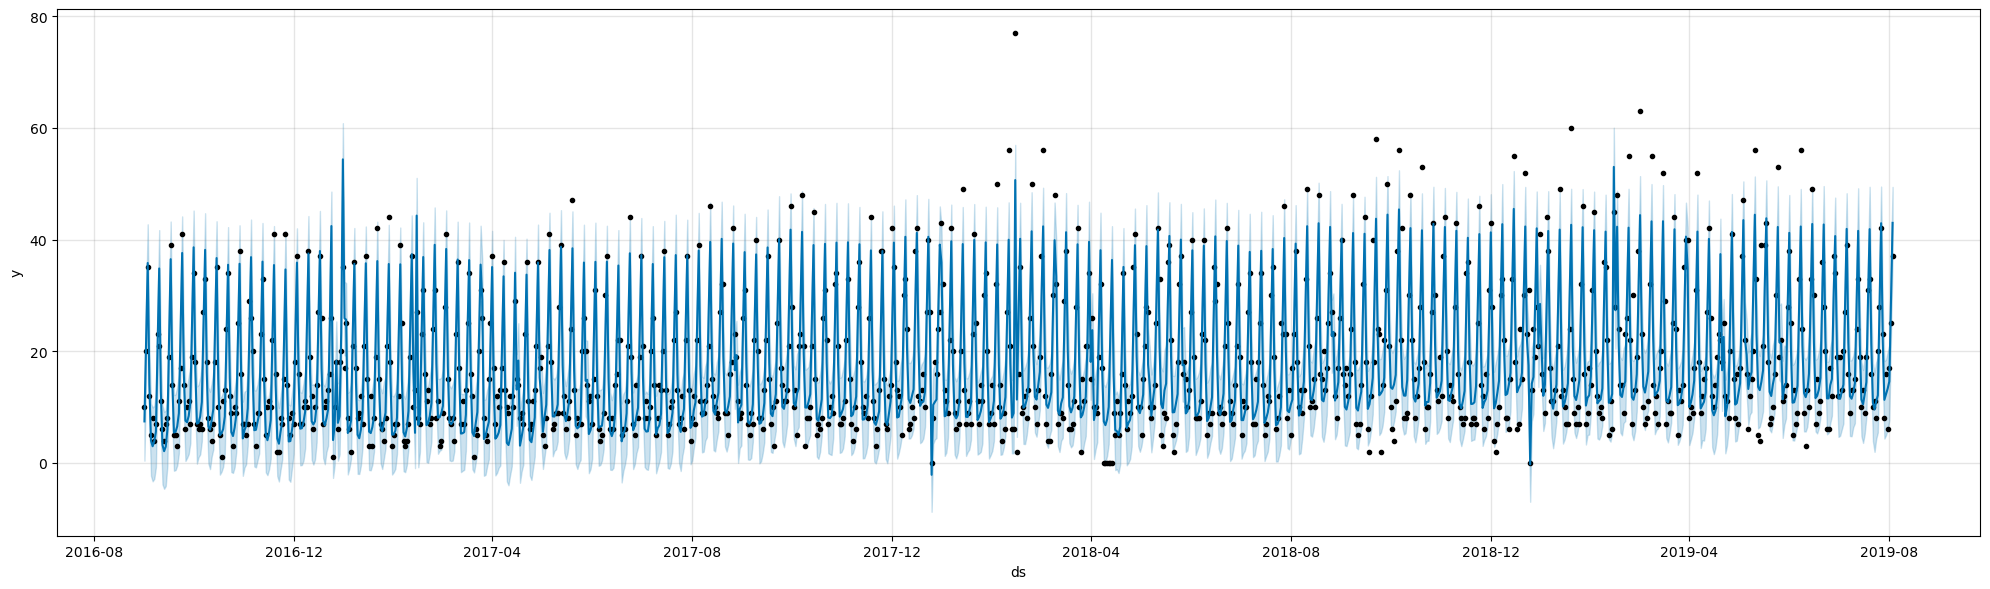

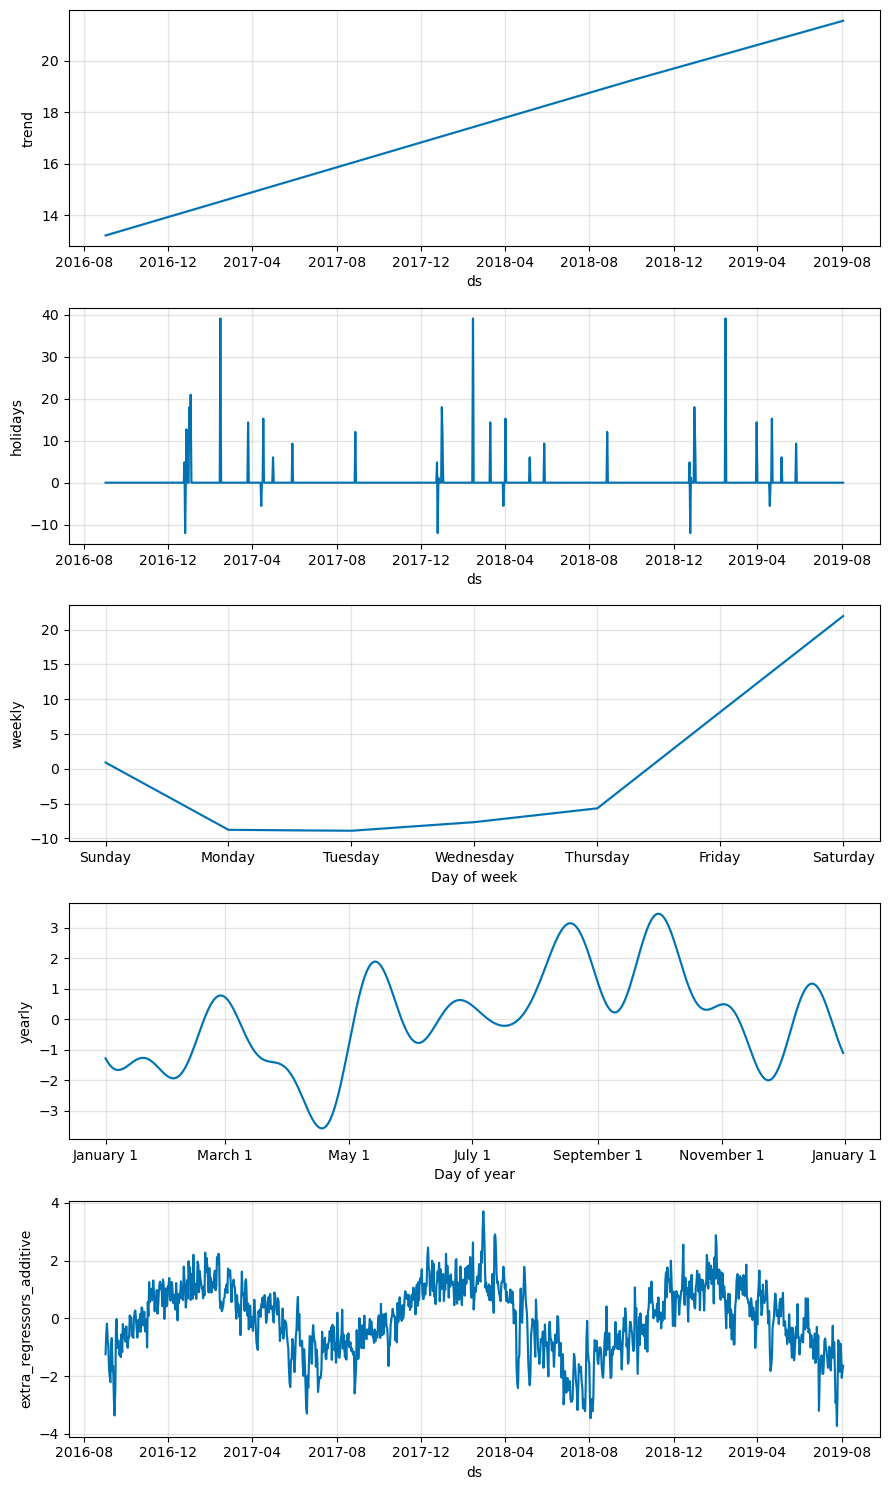

In [28]:
# Generamos una predicción sobre todo el histórico para obtener las componentes
prediccion_total = modelo_corto.predict(df_prophet[["ds"] + regresores_reducido])

# Antes de pintar las componentes, pintamos como el modelo
fig = modelo_corto.plot(prediccion_total, figsize=(20, 6))
plt.tight_layout()
plt.show()

# Prophet tiene un método plot_components integrado
fig = modelo_corto.plot_components(prediccion_total)
plt.tight_layout()
plt.show()

### Valoración:

La descomposición confirma la coherencia de los patrones aprendidos
por el modelo con el conocimiento del dominio.

**Tendencia**: la componente refleja un crecimiento progresivo y
sostenido del negocio durante el periodo analizado, pasando de unos 
13 pedidos diarios en septiembre de 2016 a unos 22 en agosto de 
2019. Este crecimiento es coherente con la consolidación de la 
clientela de un restaurante con reparto a domicilio que opera de 
forma continuada en su zona.

**Festivos**: el componente captura efectos de magnitud notable, con
picos de hasta +40 pedidos sobre el nivel de base (correspondiente 
a San Valentín de 2018, identificado en el notebook de 
enriquecimiento como el día con mayor demanda de toda la serie) y 
valles de hasta -10 pedidos. La presencia de festividades sociales
recurrentes en la lista (San Valentín, Mother's Day, Nochebuena,
Nochevieja) junto a los festivos oficiales del Reino Unido se
manifiesta en la heterogeneidad de magnitudes y signos del componente.

**Estacionalidad semanal**: el patrón aprendido es el característico
del sector, con sábado como día de mayor demanda (+22 pedidos sobre
la media semanal) y lunes y martes como los más flojos (-9 pedidos).
La diferencia neta entre el día más fuerte y el más débil es de 
aproximadamente 30 pedidos, lo que evidencia que la estacionalidad 
semanal es la señal más fuerte del modelo.

**Estacionalidad anual**: el componente oscila entre -3 y +3 pedidos
con un patrón ligeramente más alto en otoño-invierno (octubre-febrero)
que en primavera (marzo-mayo), coherente con el efecto estacional 
de mayor demanda de comida a domicilio en los meses fríos.

**Regresores meteorológicos**: el componente aditivo del conjunto
reducido oscila entre -3 y +3 pedidos. Aporta granularidad sobre
la estacionalidad anual de fondo, capturando días concretos donde
las condiciones meteorológicas se desvían del patrón estacional 
medio (un día especialmente frío en primavera, un día sorprendentemente
templado en invierno, un día de viento fuerte en verano). Aunque
la mejora cuantitativa que aporta sobre el modelo con solo festivos
en validación cruzada es operativamente despreciable, el componente
sí está aprendido y aportará valor en periodos con condiciones 
meteorológicas más extremas que las observadas en la ventana de 
modelado.

En conjunto, la descomposición valida que el modelo final captura
las cuatro fuentes de variabilidad esperables en la serie (tendencia,
patrón semanal, ciclo anual y efectos contextuales) y los pondera
con magnitudes coherentes con el conocimiento del dominio.

## 20. Resumen y próximos pasos

Al finalizar este notebook se han construido y evaluado
empíricamente dos modelos predictivos basados en Prophet, alineados
con los dos escenarios de uso del sistema en producción.

Los pasos realizados han sido:

- Carga del dataset enriquecido y preparación del formato Prophet.
- División inicial en train/test (último trimestre) para
  comparaciones rápidas entre variantes.
- Entrenamiento y evaluación de seis variantes progresivas del modelo:
  base, con festivos, con clima en distintas agregaciones, y con
  conjunto reducido de regresores.
- Análisis de los coeficientes aprendidos en modo MCMC, que reveló
  dos hallazgos clave:
  - Multicolinealidad entre las variantes 24h y ventana de servicio
    del mismo fenómeno meteorológico, con coeficientes de signos
    opuestos en los cinco pares.
  - Existencia de un subconjunto de variables con significancia
    estadística y signo coherente con el dominio (temperatura del
    día completo, viento en ventana de servicio y nubosidad del
    día completo).
- Replanteamiento del proceso de evaluación tras identificar la
  incoherencia entre el horizonte de validación y el de las
  previsiones meteorológicas disponibles en producción.
- Validación cruzada temporal en dos escenarios operativos: corto 
  plazo (14 días, con clima viable) y medio plazo (30 días, sin clima).
  El conjunto reducido obtuvo métricas operativamente equivalentes 
  al modelo con solo festivos en el escenario corto, lo que motivó 
  su mantenimiento como conjunto de regresores en el modelo final 
  por flexibilidad metodológica del sistema.
- Entrenamiento de los modelos finales sobre el dataset completo y
  persistencia de ambos en `data/processed/`.
- Inspección visual de las componentes del modelo, que validó la
  coherencia de los patrones aprendidos con el conocimiento del
  dominio. La descomposición confirmó la presencia de un componente
  meteorológico aditivo de magnitud moderada (oscilación entre
  -3 y +3 pedidos) que refina la predicción sobre la estacionalidad
  anual de fondo.

### Modelos finales

- **Modelo de corto plazo** (`modelo_prophet_corto.pkl`): Prophet con
  festivos y conjunto reducido de regresores meteorológicos
  (`temp_media_dia`, `viento_medio_serv`, `nubosidad_media_dia`).
  Horizonte recomendado: hasta 14 días.
- **Modelo de medio plazo** (`modelo_prophet_medio.pkl`): Prophet con
  festivos, sin regresores meteorológicos. Horizonte recomendado:
  hasta 30 días.

La incorporación del clima en el modelo de corto plazo se mantiene 
por dos razones complementarias. Primero, la coherencia con el 
análisis empírico del notebook de enriquecimiento, que evidenció 
efectos meteorológicos sobre la demanda en el dataset histórico 
(frío extremo del 4 de enero de 2019, efecto multiplicador del 
clima sobre San Valentín 2018). Segundo, la flexibilidad metodológica 
que permite extrapolar el sistema a otros restaurantes donde el 
clima pueda tener mayor capacidad explicativa que la observada en 
el caso de estudio.

### Próximos pasos

El siguiente notebook (`04_modelo_sarima.ipynb`) implementará el
modelo SARIMA como referencia comparativa, permitiendo contrastar la
aportación del modelo principal frente a un enfoque estadístico
clásico sin información externa.